In [1]:
%matplotlib widget

## 04. Use a lasso selector to remove inaccurate radar picks

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import rasterio as rio
from sklearn.metrics import r2_score, mean_squared_error 
import seaborn as sns
from scipy.interpolate import interp1d
from matplotlib.widgets import Slider, RectangleSelector, Button, LassoSelector
from matplotlib.path import Path
import time

class SelectFromCollection:
    def __init__(self, ax, collection, alpha_other=0.3):
        self.canvas = ax.figure.canvas
        self.collection = collection
        self.alpha_other = alpha_other

        self.xys = collection.get_offsets()
        self.Npts = len(self.xys)

        # Ensure that we have separate colors for each object
        self.fc = collection.get_facecolors()
        if len(self.fc) == 0:
            raise ValueError('Collection must have a facecolor')
        elif len(self.fc) == 1:
            self.fc = np.tile(self.fc, (self.Npts, 1))

        self.lasso = LassoSelector(ax, onselect=self.onselect, props={'color': 'cyan'})
        self.ind = []

    def onselect(self, verts):
        path = Path(verts)
        self.ind = np.nonzero(path.contains_points(self.xys))[0]
        self.fc[:, -1] = self.alpha_other
        self.fc[self.ind, -1] = 1
        self.collection.set_facecolors(self.fc)
        self.canvas.draw_idle()

    def disconnect(self):
        self.lasso.disconnect_events()
        self.fc[:, -1] = 1
        self.collection.set_facecolors(self.fc)
        self.canvas.draw_idle()

In [3]:
# reference lidar data
# referencefile = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/field_data/depth/SnwDpth_Grnd_Asp_Slp_CPC_CHM_FHD512.tif'
referencefile = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/field_data/depth/SNEX20_GM_Lidar_SD_20200201_20200202_v01.0_UTM12.tif'
file = rio.open(referencefile)
# lidar_DATA = file.read(1) # read in the first and only band (elevations)
lidar_DATA = file.read(1)*100 # convert to cm
# create the 1-m grid
grid_X = np.arange(file.bounds.left+0.5, file.bounds.right,0.9997369)
grid_Y = np.arange(file.bounds.top-0.5,file.bounds.bottom,-0.9997369)

In [4]:
rd_array_path = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start_01/' # to rd arrays
rd_output_path = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_wavelet_results/gm29Jan2020_start_01/coords/' # to output csv files

# enter in input parameters:/
velocity = 2.44e8*100 # enter in velocity to use for depth calculation [cm/s]
# velocity = 2.24e8*100 # enter in velocity to use for depth calculation [cm/s]

# grab TWT interval from TWT_vector
TWT_df = pd.read_csv(rd_array_path+'TWT_vector.csv')
TWT_interval = np.diff(TWT_df.TWT)[0]
print(TWT_interval)

1.015625e-11


In [5]:
# # MANUALLY SET
final_intercept = 18 # Centimeters
depth_shift = final_intercept
pixel_shift = round(final_intercept*2/velocity/TWT_interval)
print(depth_shift, 'cm  = ',pixel_shift, 'pixels')

18 cm  =  145 pixels


# Start by filtering ground picks

In [6]:
parameter_combo = '500scale_150size_1.0mod' # set this for all
# parameter_combo ='700scale_75size_1.25mod' # set this for all
rd_output_files = glob.glob(rd_output_path+'*'+parameter_combo+'.csv')
rd_output_files.sort()
# print(rd_output_files)

In [7]:
# check for empty coordinates
dfs = []
for file in rd_output_files:
    df = pd.read_csv(file)
    dfs.append(df)
all_coords_df = pd.concat(dfs); all_coords_df = all_coords_df.dropna(subset=['x','y']) # drop empty x,ys
if len(all_coords_df) == 0:
    print('NO X,Y COORDS FOR THE TRANSECT FOLDER. SKIP')
# all_coords_df

rd78
2527


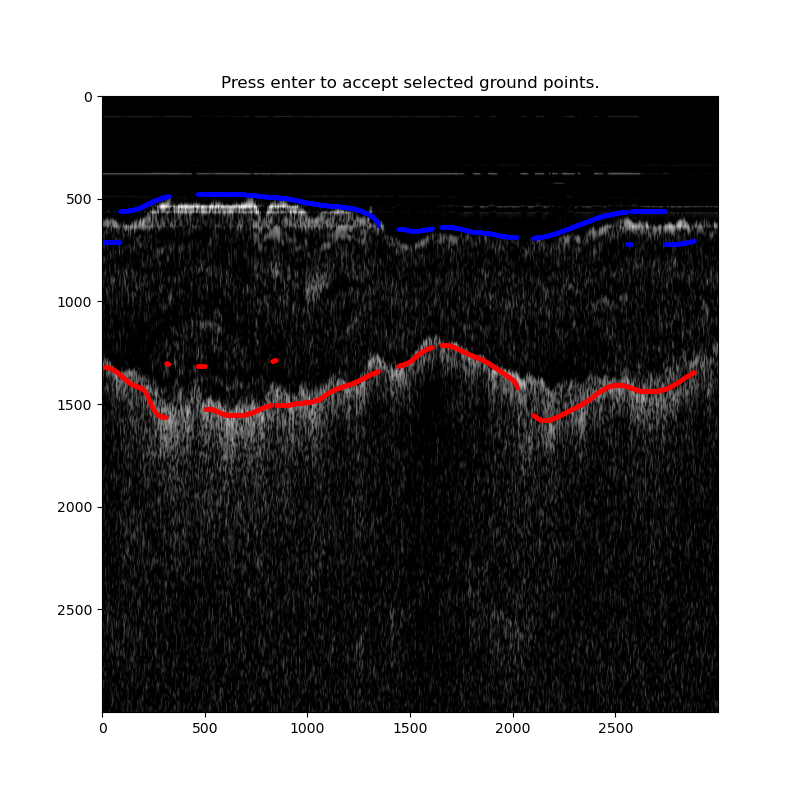

In [8]:
# Loop through radargrams for manual intervention
filtered_outpath = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_wavelet_results/gm29Jan2020_start_01/filtered/'
if not os.path.exists(filtered_outpath): # create folder if it doesn't exist already
    os.mkdir(filtered_outpath)

CURRENT_RD = 'rd78' # MANUALLY CHANGE THIS3
rd = np.load(glob.glob(rd_array_path+CURRENT_RD+'_preprocessed.npy')[0])
coords_df = pd.read_csv(rd_output_path+CURRENT_RD+'_'+parameter_combo+'.csv').dropna(subset=['x','y'])
coords_df = coords_df.reset_index()
print(CURRENT_RD)
print(len(coords_df))

# FILTER GROUND POINTS
fig, ax = plt.subplots(figsize=(8,8))
im1 = ax.imshow(rd,cmap='Greys_r') # plot radargram
# # ax2 = ax.twinx(); ax2.set_ylim(rd.shape[0],0)
surf_pts = ax.scatter(coords_df.rd_xidx, coords_df.Isurf, color='blue',s=3)
ground_pts = ax.scatter(coords_df.rd_xidx, coords_df.Iground-pixel_shift, color='red',s=3)
# ax.legend(['surface','ground'],loc='lower right')
ax.set_title(CURRENT_RD)

selector = SelectFromCollection(ax,ground_pts) # ground points
def accept(event):
    if event.key == "enter":
        print("Selected point")
        print(selector.xys[selector.ind])
        selector.disconnect()
        ax.set_
        title("")
        fig.canvas.draw()

fig.canvas.mpl_connect("key_press_event", accept)
ax.set_title("Press enter to accept selected ground points.")
plt.show()

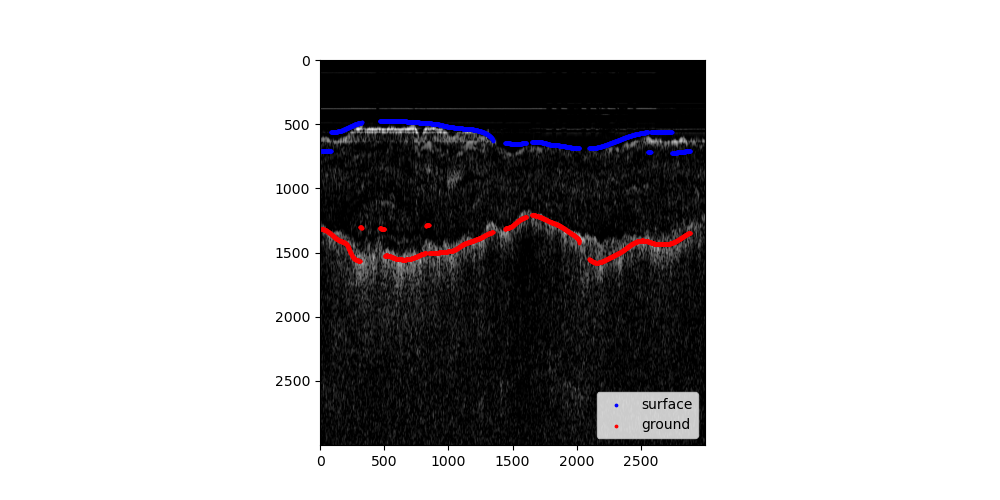

In [9]:
filtered_df = coords_df.drop(selector.ind).reset_index(drop=True) # drop the selected data
# revisualize
fig, ax = plt.subplots(figsize=(10,5))
im1 = ax.imshow(rd,cmap ='Greys_r') # plot radargram
surf_pts = ax.scatter(filtered_df.rd_xidx, filtered_df.Isurf, color='blue',s=3)
ground_pts = ax.scatter(filtered_df.rd_xidx, filtered_df.Iground-pixel_shift, color='red',s=3)
ax.legend(['surface','ground'],loc='lower right')
plt.show()

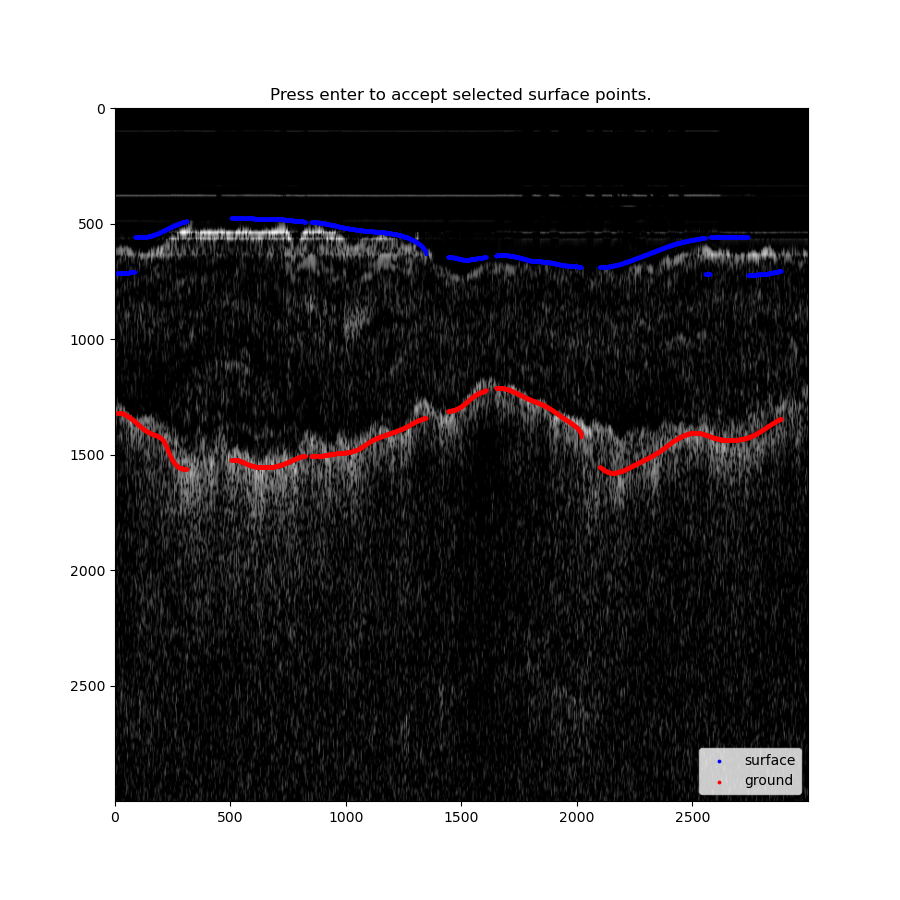

In [16]:
# select by surface points!
# filtered_df = check_df; rd=np.load(glob.glob(rd_array_path+CURRENT_RD+'_preprocessed.npy')[0])

fig, ax = plt.subplots(figsize=(9,9))
im1 = ax.imshow(rd,cmap='Greys_r') # plot radargram
# ax2 = ax.twinx(); ax2.set_ylim(rd.shape[0],0)
surf_pts = ax.scatter(filtered_df.rd_xidx, filtered_df.Isurf, color='blue',s=3)
ground_pts = ax.scatter(filtered_df.rd_xidx, filtered_df.Iground-pixel_shift, color='red',s=3)
ax.legend(['surface','ground'],loc='lower right')
ax.set_title(CURRENT_RD)

selector = SelectFromCollection(ax, surf_pts) # ground points if needed
def accept(event):
    if event.key == "enter":
        print("Selected points:")
        print(selector.xys[selector.ind])
        selector.disconnect()
        ax.set_title("")
        fig.canvas.draw()

fig.canvas.mpl_connect("key_press_event", accept)
ax.set_title("Press enter to accept selected surface points.")
plt.show()

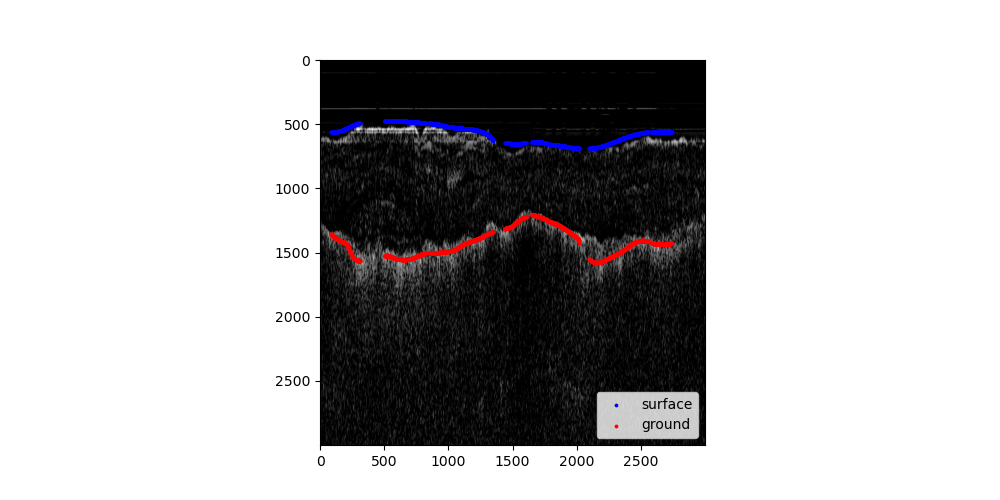

In [17]:
# show
filtered_df = filtered_df.drop(list(selector.ind)) # drop the selected data
# revisualize
fig, ax = plt.subplots(figsize=(10,5))
im1 = ax.imshow(rd,cmap='Greys_r') # plot radargram
surf_pts = ax.scatter(filtered_df.rd_xidx, filtered_df.Isurf, color='blue',s=3)
ground_pts = ax.scatter(filtered_df.rd_xidx, filtered_df.Iground-pixel_shift, color='red',s=3)
ax.legend(['surface','ground'],loc='lower right')
plt.show()

### Additional filtering

In [ ]:
# OPTIONAL - filter out by index
# filtered_df = filtered_df[filtered_df.rd_xidx < 2300] # right edge
filtered_df = filtered_df[filtered_df.rd_xidx > 50] # left edge

plt.scatter(filtered_df.rd_xidx, filtered_df.Iground-pixel_shift, s=2) # plot filtered pts in light blue over rd
plt.show()

In [ ]:
# OPTIONAL filter by surface depth (vertical index)
filtered_df = filtered_df[filtered_df.Isurf <= 700]

plt.scatter(filtered_df.rd_xidx, filtered_df.Isurf, s=2) # plot filtered pts in light blue over rd
plt.show()

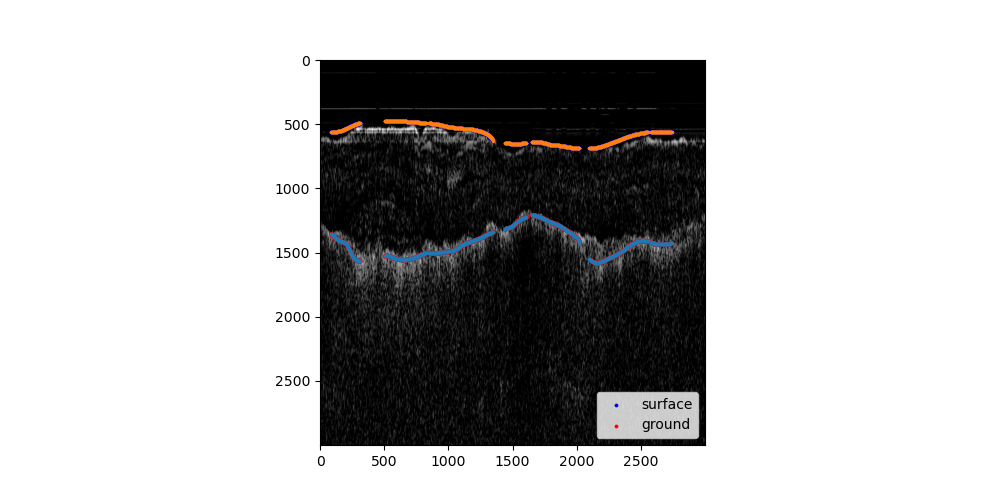

In [18]:
# OPTIONAL - filter by ground depth (vertical index)
filtered_df = filtered_df[filtered_df.Iground-pixel_shift <= 2000]

plt.scatter(filtered_df.rd_xidx, filtered_df.Iground-pixel_shift,s=2) # plot filtered pts 
plt.scatter(filtered_df.rd_xidx, filtered_df.Isurf, s=2) # plot filtered pts
plt.show()

### Save filtered dataset:

In [19]:
# save
filtered_df.to_csv(filtered_outpath+CURRENT_RD+'_'+parameter_combo+'_filtered.csv') # write to CSV
print(CURRENT_RD)

rd78


#### Check after saving:

In [ ]:
### check after saving
import pandas as pd; import numpy as np; import matplotlib.pyplot as plt; import glob
rd_array_path = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed/gm29Jan2020_start_01/'
filtered_outpath = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_wavelet_results/gm29Jan2020_start_01/filtered/'
CURRENT_RD = 'rd72'
targetfile = glob.glob(filtered_outpath+CURRENT_RD+'*filtered.csv')[0]
check_df = pd.read_csv(targetfile); rd = np.load(rd_array_path+CURRENT_RD+'_preprocessed.npy')

fig, ax = plt.subplots(figsize=(10,4)); ax2 = ax.twinx(); ymin = 400; ylim = 800
# im1 = ax.imshow(rd,cmap='Greys_r') # plot radargram
ax.scatter(check_df.rd_xidx, check_df.Isurf, color='b', s=2) # plot filtered pts in light blue over rd
ax.scatter(check_df.rd_xidx, check_df.Iground, color='r',s=2) # plot filtered pts in light blue over rd
ax.set_ylim(ymin,ylim); ax2.set_ylim(ymin,ylim); ax.set_xlim(0,rd.shape[0])
ax.invert_yaxis(); ax2.invert_yaxis(); ax.grid(); plt.show()

In [ ]:
check_df = check_df[check_df.Isurf <= 700]
# check_df = check_df[check_df.rd_xidx >= 200]
# check_df = check_df[check_df.Iground <= 2000]
check_df.to_csv(targetfile)

In [ ]:
# adjust the rd_id on some
gmpath= '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/'
NEWID = 'rd3'
targetfile = glob.glob(gmpath+'FMCW_wavelet_results_bigDrift_redone/filtered/'+NEWID+'*.csv')[0]
target_df = pd.read_csv(targetfile)
target_df['rd_id'] = NEWID
target_df.head()

In [ ]:
target_df.to_csv(targetfile) # overwrite